# 01v2 — Data Exploration

toute la logique est dans `src/analyses/dataset_analysis.py`.

In [2]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
from experiments.mmused_text import make_mmused_fallacy_loader

loader_afc = make_mmused_fallacy_loader('afc')
loader_afd = make_mmused_fallacy_loader('afd')

print('AFC:', loader_afc.data.shape)
print('AFD:', loader_afd.data.shape)

/workspace/patootie_code/mm_argfallacy/mmarg_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Building AFC Context: 100%|██████████| 1278/1278 [00:00<00:00, 11294.63it/s]


AFC: (1278, 8)


Building AFD data...: 100%|██████████| 35/35 [00:02<00:00, 11.88it/s]


AFD: (17118, 7)


## 1. Distribution des classes

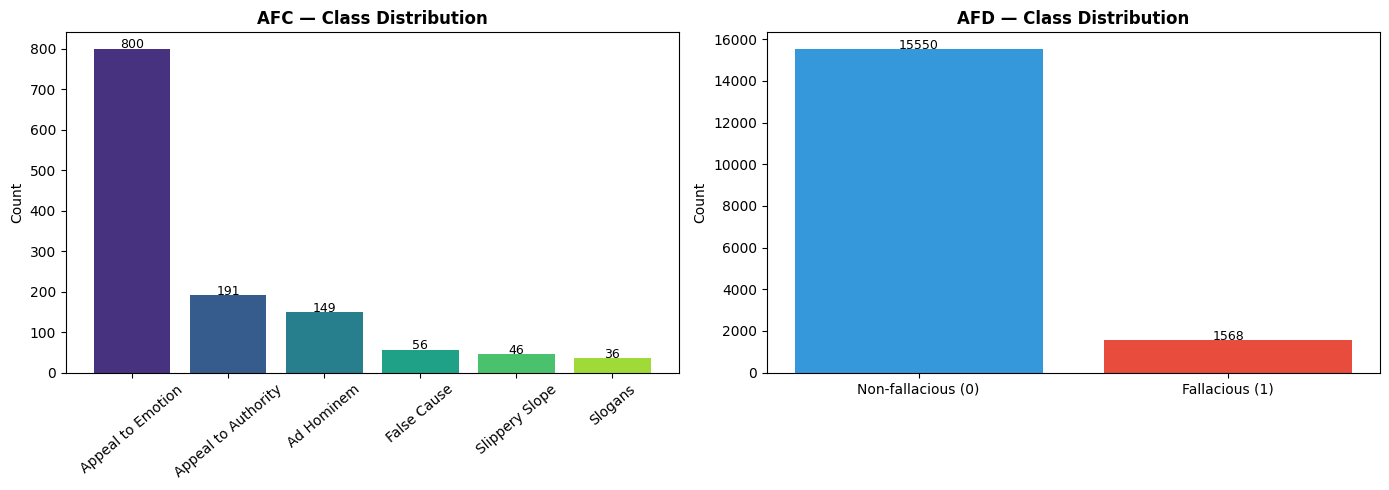

In [4]:
from analyses.dataset_analysis import plot_class_distributions

plot_class_distributions(
    loader_afc, loader_afd,
    save_dir=FIG_DIR
)

## 2. Poids des classes (class weights)

In [5]:
from analyses.dataset_analysis import print_class_weights

print_class_weights(
    loader_afc, loader_afd,
    save_path=ROOT / 'data' / 'class_weights.json'
)

=== AFC class weights ===
Class                          N       %   Weight
  Appeal to Emotion          800   62.6%   0.2662
  Appeal to Authority        191   14.9%   1.1152
  Ad Hominem                 149   11.7%   1.4295
  False Cause                 56    4.4%   3.8036
  Slippery Slope              46    3.6%   4.6304
  Slogans                     36    2.8%   5.9167

=== AFD class weights ===
  Non-fallacious           15550   90.8%   0.5504
  Fallacious                1568    9.2%   5.4585

Saved to /workspace/patootie_code/mm_argfallacy/data/class_weights.json


## 3. Longueur des snippets / phrases

/workspace/patootie_code/mm_argfallacy/src/analyses/dataset_analysis.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_afc, x="fallacy", y="n_words", palette="viridis", ax=axes[0, 1])


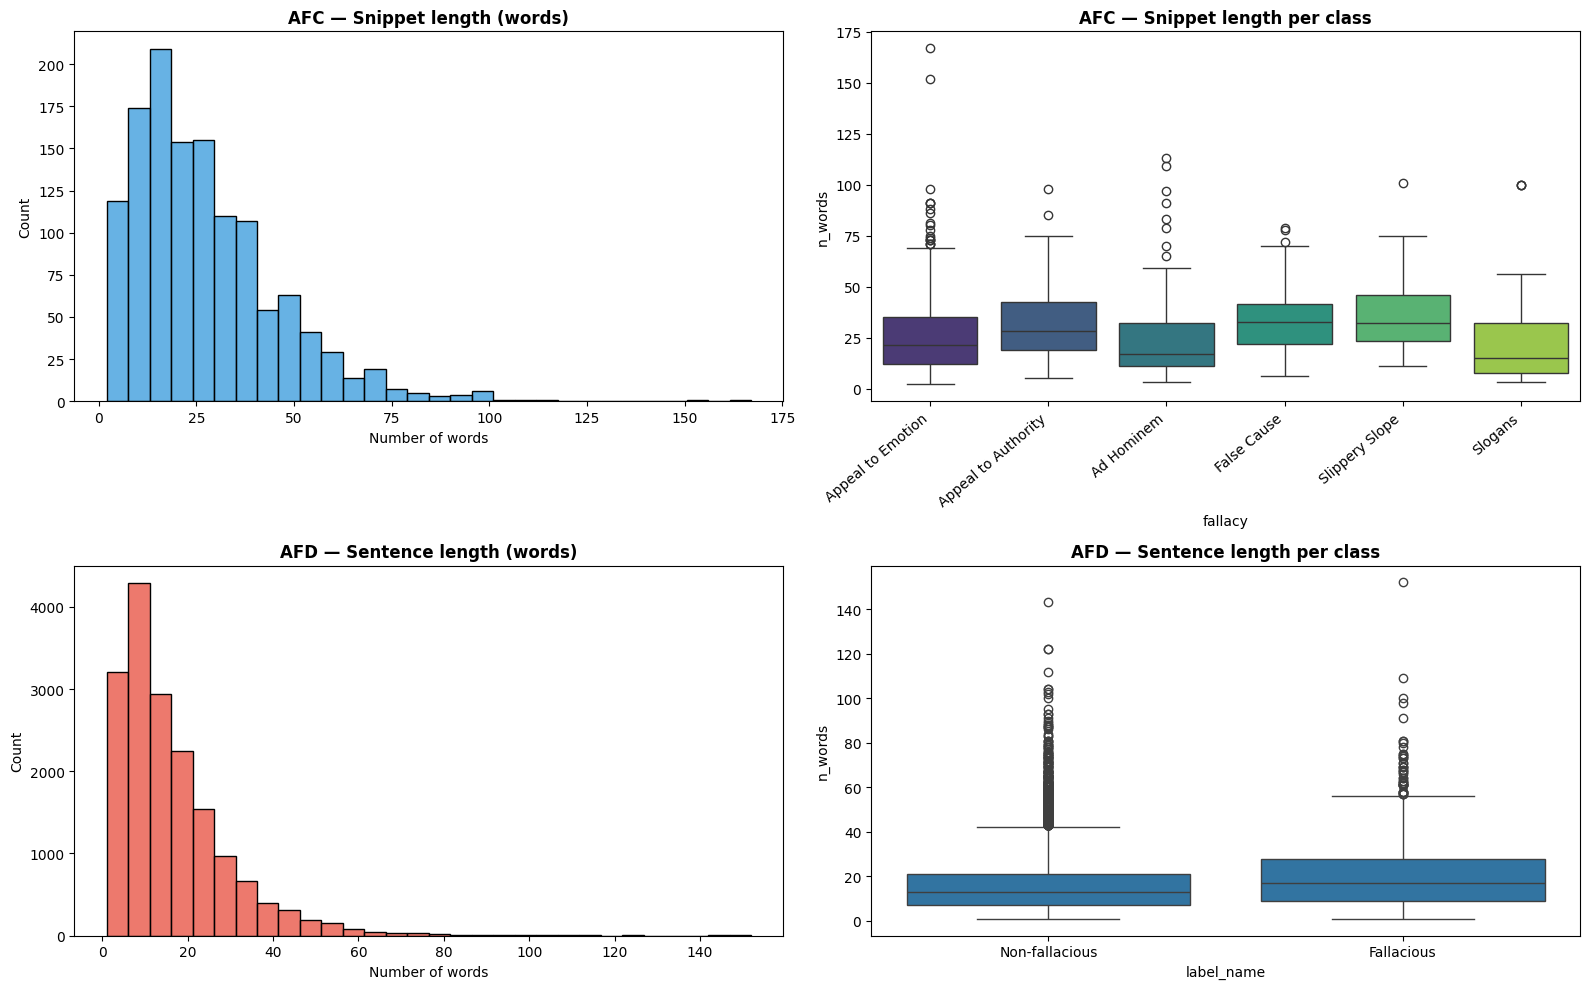

In [6]:
from analyses.dataset_analysis import plot_snippet_lengths

plot_snippet_lengths(
    loader_afc, loader_afd,
    save_dir=FIG_DIR
)

## 4. Statistiques par dialogue

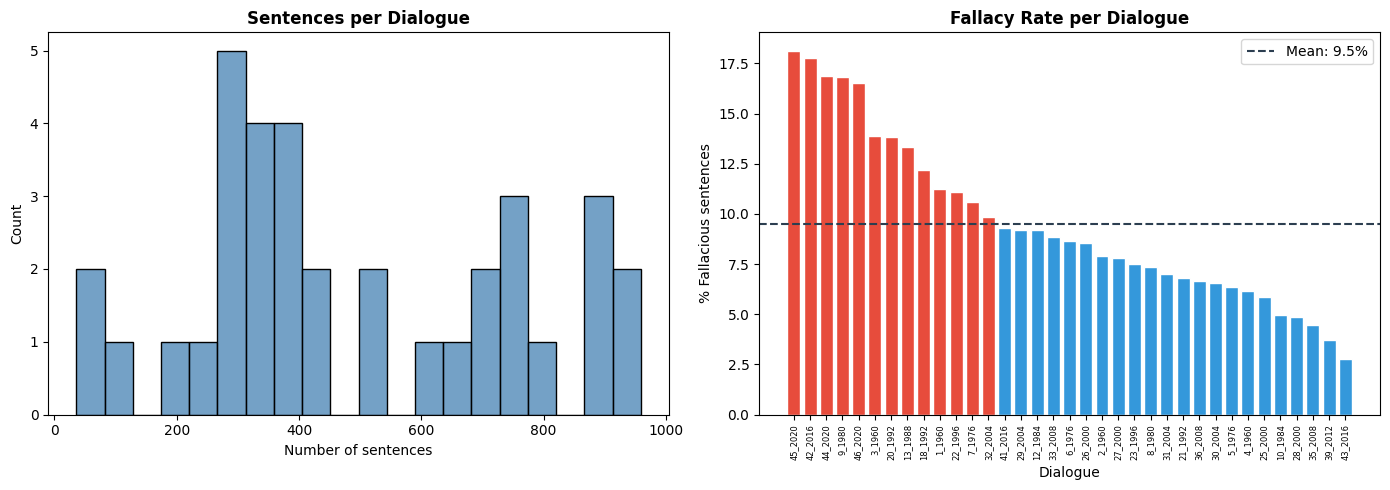

Sentences/dialogue — mean: 489.1  median: 405.0  max: 959
Fallacy rate       — mean: 9.5%  max: 18.1%


In [7]:
from analyses.dataset_analysis import plot_dialogue_stats

plot_dialogue_stats(loader_afd, save_dir=FIG_DIR)

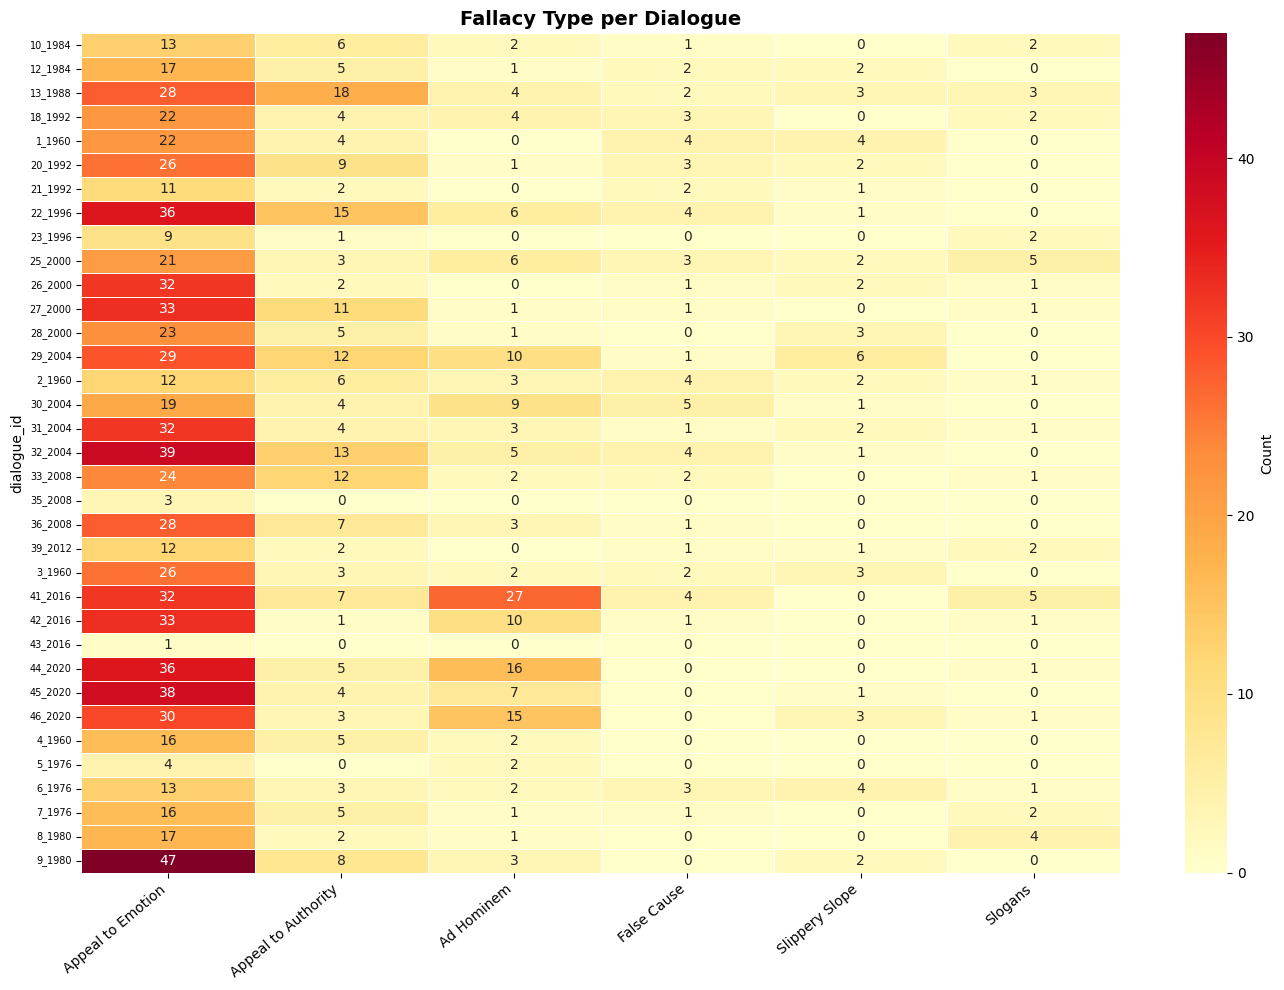

In [8]:
from analyses.dataset_analysis import plot_fallacy_heatmap

plot_fallacy_heatmap(loader_afc, save_dir=FIG_DIR)

## 5. Exemples et diagnostics

In [9]:
from analyses.dataset_analysis import print_examples

print_examples(loader_afc, loader_afd, n=2)

=== AFC — examples per class ===

--- Appeal to Emotion ---
  1. And there are other ways of squeezing this budget without constantly picking on our senior citizens and the most vulnerable in American life.
  2. And you let those people go with the guidelines of overall policy, not looking over their shoulder and nitpicking the manner in which they go at the job.

--- Appeal to Authority ---
  1. In mine, I happen to believe in the people and believe that the people are supposed to be dominant in our society -- that they, not government, are to have control of their own affairs to the greatest
  2. And when people vote, I think you're going to see a very strong verdict by the American people that they favor the approach that I'm talking about.

--- Ad Hominem ---
  1. Well, the other day, Vice President Bush disclosed his tax returns to the American people. He's one of the wealthiest Americans, and he's our Vice President. In 1981 I think he paid about 40 percent i
  2. America is a fa

In [10]:
from analyses.dataset_analysis import print_afd_diagnostics

print_afd_diagnostics(loader_afd)

Sentences appearing in >1 dialogue: 86
 n_dialogues                                                                                                                            dialogues
          15 [10_1984, 12_1984, 20_1992, 23_1996, 25_2000, 26_2000, 27_2000, 30_2004, 31_2004, 32_2004, 35_2008, 3_1960, 44_2020, 5_1976, 9_1980]
          13                 [10_1984, 18_1992, 21_1992, 22_1996, 28_2000, 29_2004, 30_2004, 31_2004, 32_2004, 35_2008, 39_2012, 45_2020, 9_1980]
           9                                                    [10_1984, 18_1992, 22_1996, 25_2000, 27_2000, 30_2004, 31_2004, 36_2008, 42_2016]
           7                                                                       [13_1988, 21_1992, 28_2000, 32_2004, 36_2008, 39_2012, 7_1976]
           6                                                                               [21_1992, 26_2000, 27_2000, 31_2004, 36_2008, 42_2016]
           5                                                                         

/workspace/patootie_code/mm_argfallacy/src/analyses/dataset_analysis.py:213: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .agg(n_dialogues=("dialogue_id", "nunique"),
